# Eddies VS changes in sea ice thickness

EIP pumping theory shows that EIP happens mostly in Anticyclonic eddies. Do we see a change in SIT especially in anticyclonic eddies with resolution?

**This notebook needs to be run in a hugemem queue. Importing the daily fields also take a considerable time**

In [3]:
import intake
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import cf_xarray as cf
import xarray as xr
import cmocean.cm as cmocean
import glob
from mpl_toolkits.axes_grid1 import make_axes_locatable
import shutil as shutil
from dask.distributed import Client
from scipy import ndimage
from skimage import measure
import pandas as pd
import plotly.express as px
import warnings

In [4]:
client = Client(threads_per_worker = 1,memory_limit='2900gb')

2025-10-08 10:51:40,738 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-08 10:51:40,746 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-08 10:51:40,753 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-08 10:51:40,760 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-08 10:51:40,767 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-08 10:51:40,774 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-08 10:51:40,781 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-08 10:51:40,

In [5]:
#setting the reference rho
rho_ref = 1035 #kg m^{-3}, used as standard by Pan-Antarctic
#using a single year of data
start_date='2000-01-01'
end_date = '2001-01-01'

Importing pre-calculated Okubo-Weiss parameters ($W$)

In [6]:
# Base vorticity variables directory
base_vortdir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'
#importing
OW_0025 = xr.open_mfdataset(base_vortdir + 'panan0025_rerun/EKE_along_contour/Okubo_Wiess_panan0025.nc').\
    sel(time=slice(start_date,end_date)).OkuboWeiss.chunk(chunks={"time":'200gb'}).compute()
OW_005 = xr.open_mfdataset(base_vortdir + 'panan005_rerun/EKE_along_contour/Okubo_Wiess_panan005.nc').\
    sel(time=slice(start_date,end_date)).OkuboWeiss.chunk(chunks={"time":'200gb'}).compute()
OW_01 = xr.open_mfdataset(base_vortdir + 'panan01_rerun/EKE_along_contour/Okubo_Wiess_panan01.nc').\
    sel(time=slice(start_date,end_date)).OkuboWeiss.chunk(chunks={"time":'200gb'}).compute()

In [7]:
#importing vorticity for sanity check
# # # Panan0025
ζ_0025 = xr.open_mfdataset(base_vortdir + 'panan0025_rerun/EKE_along_contour/vorticity_xyt_*_panan0025.nc')\
    .Surface_Vorticity.sel(time=slice(start_date,end_date)).chunk(chunks={"time":'200gb'}).compute()
# # # Panan005
ζ_005 = xr.open_mfdataset(base_vortdir + 'panan005_rerun/EKE_along_contour/vorticity_xyt_panan005.nc')\
    .Surface_Vorticity.sel(time=slice(start_date,end_date)).chunk(chunks={"time":'200gb'}).compute()
# # # Panan005
ζ_01 = xr.open_mfdataset(base_vortdir + 'panan01_rerun/EKE_along_contour/vorticity_xyt_panan01.nc')\
    .Surface_Vorticity.sel(time=slice(start_date,end_date)).chunk(chunks={"time":'200gb'}).compute()

In [8]:
#in this definition, no frequency can be used only for static data
catalog = intake.cat.access_nri
def importer(experiment,catalog,variable, frequency = 'fx',start_time=0,end_time=0):
    warnings.filterwarnings('ignore')
    if experiment== "panant-01-zstar-ACCESSyr2":
        var = catalog[experiment].search(variable=variable, frequency = frequency).to_dask(xarray_open_kwargs={'decode_timedelta':True})
    else: 
        #other resolutions have the same variable with z_l and z_l_sub z dim in different times.
        # I will filter to the time I want knowing th their specificities
        #IOW this fix works just for the models and variables used in this notebook
        if variable=='uo' or variable=='vo':
            var = catalog[experiment].search(variable=variable, frequency = frequency)
            keysnames = var.keys() ; search_term = "z_l_sub01"
            matches = [s for s in keysnames if search_term in s]
            var = catalog[experiment].search(variable=variable, frequency = frequency,file_id = matches).to_dask(xarray_open_kwargs={'decode_timedelta':True})
        else:
            var = catalog[experiment].search(variable=variable, frequency = frequency).to_dask(xarray_open_kwargs={'decode_timedelta':True})
    
    if start_time!=0:
        time_slice='slice(start_time,end_time)'
        return eval("var." + variable + ".sel(time=" + time_slice + ")")
    elif start_time ==0:
        return eval("var." + variable)

In [9]:
#importing grid cell area
areacello_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,"areacello_bu").sel(yq=slice(OW_0025.yq.min(),OW_0025.yq.max())).compute()
areacello_005 = importer("panant-005-zstar-ACCESSyr2",catalog,"areacello_bu").sel(yq=slice(OW_005.yq.min(),OW_005.yq.max())).compute()
areacello_01 = importer("panant-01-zstar-ACCESSyr2",catalog,"areacello_bu").sel(yq=slice(OW_01.yq.min(),OW_01.yq.max())).compute()

In [10]:
#eddy size detector
def eddy_sizes_xarray(binary_mask, area_grid, min_pixels=1):
    """
    Detect eddies from a binary mask and compute their size metrics.
    
    Parameters
    ----------
    binary_mask : xarray.DataArray
        Boolean or 0/1 mask with dims (time, lat, lon) or (lat, lon).
    area_grid : xarray.DataArray
        Grid-cell areas [m^2], dims (lat, lon).
    min_pixels : int
        Minimum number of connected pixels to keep an eddy.
    
    Returns
    -------
    eddies : xarray.Dataset
        Dataset with one row per eddy containing:
        - time (if applicable)
        - eddy_id (per timestep)
        - n_pixels
        - area_m2
        - radius_m
        - centroid_lat
        - centroid_lon
    """

    # Ensure inputs are DataArrays
    if not isinstance(binary_mask, xr.DataArray):
        raise ValueError("binary_mask must be an xarray.DataArray")
    if not isinstance(area_grid, xr.DataArray):
        raise ValueError("area_grid must be an xarray.DataArray")

    lat = binary_mask["yq"].values
    lon = binary_mask["xq"].values
    area_grid_vals = area_grid.values

    has_time = "time" in binary_mask.dims
    if not has_time:
        binary_mask = binary_mask.expand_dims(time=[0])  # add dummy time

    records = []
    for t_idx, t_val in enumerate(binary_mask["time"].values):
        mask = binary_mask.isel(time=t_idx).values.astype(bool)
        labeled, ncomp = ndimage.label(mask)
        props = measure.regionprops(labeled)
        for eddy_id, prop in enumerate(props, start=1):
            if prop.area < min_pixels:
                continue
            coords = prop.coords
            area_m2 = area_grid_vals[coords[:, 0], coords[:, 1]].sum()
            eq_radius_m = np.sqrt(area_m2 / np.pi)
            r, c = prop.centroid
            centroid_lat = np.interp(r, np.arange(len(lat)), lat)
            centroid_lon = np.interp(c, np.arange(len(lon)), lon)
            records.append({
                "time": t_val,
                "eddy_id": eddy_id,
                "n_pixels": int(prop.area),
                "area_m2": float(area_m2),
                "radius_m": float(eq_radius_m),
                "centroid_lat": float(centroid_lat),
                "centroid_lon": float(centroid_lon)
            })

    if not records:
        return xr.Dataset()  # empty

    # Convert records -> pandas -> xarray.Dataset
    df = pd.DataFrame.from_records(records)
    eddies = xr.Dataset.from_dataframe(df.set_index(["time", "eddy_id"]))

    return eddies

In [11]:
# Importing detection masks
Detection_masked_0025 = xr.open_dataset(base_vortdir + 'panan0025_rerun/EKE_along_contour/Okubo_Wiess_mask0025_02threshold_panan0025.nc').OkuboWeiss_mask0025
Detection_masked_005 = xr.open_dataset(base_vortdir + 'panan005_rerun/EKE_along_contour/Okubo_Wiess_mask005_02threshold_panan005.nc').OkuboWeiss_mask005
Detection_masked_01 = xr.open_dataset(base_vortdir + 'panan01_rerun/EKE_along_contour/Okubo_Wiess_mask01_02threshold_panan01.nc').OkuboWeiss_mask01

In [12]:
# Importing detection masked
Detection_mask_0025 = xr.open_dataset(base_vortdir + 'panan0025_rerun/EKE_along_contour/Okubo_Wiess_maskNaN_02threshold_panan0025.nc').OkuboWeiss_masknan
Detection_mask_005 = xr.open_dataset(base_vortdir + 'panan005_rerun/EKE_along_contour/Okubo_Wiess_maskNaN_02threshold_panan005.nc').OkuboWeiss_masknan
Detection_mask_01 = xr.open_dataset(base_vortdir + 'panan01_rerun/EKE_along_contour/Okubo_Wiess_maskNaN_02threshold_panan01.nc').OkuboWeiss_masknan

In [13]:
#Importing eddies areas
eddies_area_01 = xr.open_dataset(base_vortdir + 'panan01_rerun/EKE_along_contour/Eddies_Stats_02threshold_panan01.nc')
eddies_area_005 = xr.open_dataset(base_vortdir + 'panan005_rerun/EKE_along_contour/Eddies_Stats_02threshold_panan005.nc')
eddies_area_0025 = xr.open_dataset(base_vortdir + 'panan0025_rerun/EKE_along_contour/Eddies_Stats_02threshold_panan0025.nc')

In [14]:
# Importing ζ in eddies centroid
Eddies_ζ_centroid_0025 = xr.open_dataset(base_vortdir + 'panan0025_rerun/EKE_along_contour/Vorticity_centroid_02threshold_panan0025.nc').VorticityCentroid
Eddies_ζ_centroid_005 = xr.open_dataset(base_vortdir + 'panan005_rerun/EKE_along_contour/Vorticity_centroid_02threshold_panan005.nc').VorticityCentroid
Eddies_ζ_centroid_01 = xr.open_dataset(base_vortdir + 'panan01_rerun/EKE_along_contour/Vorticity_centroid_02threshold_panan01.nc').VorticityCentroid

### Sea ice thickness and cyclonicity

At this point the main hypothesis I have is that more eddies ans stronger eddies in higher resolution bring more heat to the Southern Ocean, but also increase heat fluxes to the surface, compensating for the stronger heat transport and making changes on the shelf minimal. To test that we need to see changes in SIT are aligned with cyclonicity of eddies. In other words, do anticylonic, cold core eddies, concentrate the alrgest decrease in sea ice thickness over the sea ice margins?

In [15]:
%%time
#importing sea ice thickness
SIT_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,"sithick",frequency = '1day',start_time = start_date, end_time =end_date).chunk(chunks={'xT':'15gb','yT':'15gb','time':'15gb'}).compute()
SIT_005 = importer("panant-005-zstar-ACCESSyr2",catalog,"sithick",frequency = '1day',start_time = start_date, end_time =end_date).chunk(chunks={'xT':'15gb','yT':'15gb','time':'15gb'}).compute()
SIT_01 = importer("panant-01-zstar-ACCESSyr2",catalog,"sithick",frequency = '1day',start_time = start_date, end_time =end_date).chunk(chunks={'xT':'15gb','yT':'15gb','time':'15gb'}).compute()



CPU times: user 7min 41s, sys: 6min, total: 13min 42s
Wall time: 15min 10s


In [16]:
#it is quite memory and time intensive to interpolate into yq grid cells, so I will just assume the SIT is the same between q and h points
SIT_01 = SIT_01.rename({'yT': 'yq', 'xT':'xq'}).sel(xq=slice(OW_01.xq.min().values,OW_01.xq.max().values)).sel(yq=slice(OW_01.yq.min().values,OW_01.yq.max().values))
SIT_01['xq'] = OW_01.xq[1:].values; SIT_01['yq'] = OW_01.yq[1:].values


SIT_005 = SIT_005.rename({'yT': 'yq', 'xT':'xq'}).sel(xq=slice(OW_005.xq.min().values,OW_005.xq.max().values)).sel(yq=slice(OW_005.yq.min().values,OW_005.yq.max().values))
SIT_005['xq'] = OW_005.xq[1:].values; SIT_005['yq'] = OW_005.yq[1:].values

SIT_0025 = SIT_0025.rename({'yT': 'yq', 'xT':'xq'}).sel(xq=slice(OW_0025.xq.min().values,OW_0025.xq.max().values)).sel(yq=slice(OW_0025.yq.min().values,OW_0025.yq.max().values))
SIT_0025['xq'] = OW_0025.xq[1:].values; SIT_0025['yq'] = OW_0025.yq[1:].values

In [17]:
#masking non-eddye areas
SIT_01_eddies = Detection_masked_01 * SIT_01
SIT_005_eddies = Detection_masked_005 * SIT_005
SIT_0025_eddies = Detection_masked_0025 * SIT_0025

In [18]:
#creating a mask for regions where sea ice exhist only
SIT_01_mask=1+(SIT_01_eddies.where(SIT_01_eddies>0)*0)
SIT_005_mask=1+(SIT_005_eddies.where(SIT_005_eddies>0)*0)
SIT_0025_mask=1+(SIT_0025_eddies.where(SIT_0025_eddies>0)*0)

We can then use xhistogram to bin the SIT in vorticity classes to see whether the sea ice thickness decrease happens mostly in anticylonic eddies

In [19]:
from xhistogram.xarray import histogram

In [41]:
#separating only the sea ice edge area, so the influxence of the shelf is minimal
Edge_lat_slice=slice(-70,-55)
#separating vorticity in the sea ice edge
ζ_01_SIedge = (SIT_01_mask * Detection_masked_01 * ζ_01).cf.sel({'latitude':Edge_lat_slice}); ζ_01_SIedge.name = 'Vorticity'
ζ_005_SIedge = (SIT_005_mask * Detection_masked_005 * ζ_005).cf.sel({'latitude':Edge_lat_slice}); ζ_005_SIedge.name = 'Vorticity'
ζ_0025_SIedge = (SIT_0025_mask * Detection_masked_0025 * ζ_0025).cf.sel({'latitude':Edge_lat_slice}); ζ_0025_SIedge.name = 'Vorticity'

#separating thickness in the sea ice edge
SIT_01_eddies_SIedge = (SIT_01_mask * SIT_01_eddies).cf.sel({'latitude':Edge_lat_slice}); SIT_01_eddies_SIedge.name = 'SIT'
SIT_005_eddies_SIedge = (SIT_005_mask * SIT_005_eddies).cf.sel({'latitude':Edge_lat_slice}); SIT_005_eddies_SIedge.name = 'SIT'
SIT_0025_eddies_SIedge = (SIT_0025_mask* SIT_0025_eddies).cf.sel({'latitude':Edge_lat_slice}); SIT_0025_eddies_SIedge.name = 'SIT'

#separating area in the sea ice edge
Area_01_eddies_SIedge = (SIT_01_mask *Detection_masked_01 * areacello_01).cf.sel({'latitude':Edge_lat_slice}); Area_01_eddies_SIedge.name = 'Area'
Area_005_eddies_SIedge = (SIT_005_mask * Detection_masked_005 * areacello_005).cf.sel({'latitude':Edge_lat_slice}); Area_005_eddies_SIedge.name = 'Area'
Area_0025_eddies_SIedge = (SIT_0025_mask* Detection_masked_0025 * areacello_0025).cf.sel({'latitude':Edge_lat_slice}); Area_0025_eddies_SIedge.name = 'Area'


In [42]:
# SIT_01_eddies_SIedge_stacked =  (SIT_01_mask* SIT_01_eddies_SIedge).stack(linear={'time','xq','yq'})
# ζ_01_SIedge_stacked =  (SIT_01_mask *ζ_01_SIedge).stack(linear={'time','xq','yq'})
# SIT_005_eddies_SIedge_stacked =  (SIT_005_mask* SIT_005_eddies_SIedge).stack(linear={'time','xq','yq'})
# ζ_005_SIedge_stacked =  (SIT_005_mask *ζ_005_SIedge).stack(linear={'time','xq','yq'})
# SIT_0025_eddies_SIedge_stacked =  (SIT_0025_mask* SIT_0025_eddies_SIedge).stack(linear={'time','xq','yq'})
# ζ_0025_SIedge_stacked =  (SIT_0025_mask *ζ_0025_SIedge).stack(linear={'time','xq','yq'})

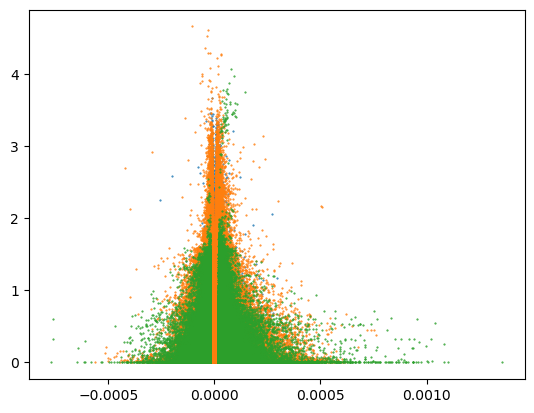

In [66]:
# plt.plot(ζ_01_SIedge_stacked,SIT_01_eddies_SIedge_stacked,'.',markersize=1)
# plt.plot(ζ_005_SIedge_stacked,SIT_005_eddies_SIedge_stacked,'.',markersize=1)
# plt.plot(ζ_0025_SIedge_stacked,SIT_0025_eddies_SIedge_stacked,'.',markersize=1)

In [61]:
#first test
#ζ_bins = np.linspace(-2e-4,2e-4,100) #initially I was using refined bins, but we have different vorticity intensities in different runs. so they dont compare that well. 
#a better approach is to use a bianry system with one bin with negative vorticity, and one bin with positive vorticity. This would objectivvely separate the effect on cyclonic and anticyclonic eddies

#bins that separate cyclonic and anticyclonic eddies
ζ_bins =  np.linspace(-2,2,3)
ζ_bins

array([-2.,  0.,  2.])

In [103]:
#binning age into sigma contours ζ_bins - panan01
#area weighted
SIT_ζbinned_01 = histogram(ζ_01_SIedge, 
                          bins = ζ_bins, 
                          dim = ['xq','yq'],
                          weights = SIT_01_eddies_SIedge*Area_01_eddies_SIedge)/\
histogram(ζ_01_SIedge, 
                          bins = ζ_bins, 
                          dim = ['xq','yq'],
                          weights = Area_01_eddies_SIedge)

# #non area weighted
# SIT_ζbinned_01 = histogram(ζ_01_SIedge, 
#                           bins = ζ_bins, 
#                           dim = ['xq','yq'],
#                           weights = SIT_01_eddies_SIedge)/\
# histogram(ζ_01_SIedge, 
#                           bins = ζ_bins, 
#                           dim = ['xq','yq'],
#                           weights = (1 +(SIT_01_eddies_SIedge*0).fillna(0)))

In [104]:
# #binning age into sigma contours ζ_bins - panan005
#area weigthed
SIT_ζbinned_005 = histogram(ζ_005_SIedge, 
                          bins = ζ_bins, 
                          dim = ['xq','yq'],
                          weights = SIT_005_eddies_SIedge*Area_005_eddies_SIedge)/\
histogram(ζ_005_SIedge, 
                          bins = ζ_bins, 
                          dim = ['xq','yq'],
                          weights = Area_005_eddies_SIedge)

# # non area weigthed
# SIT_ζbinned_005 = histogram(ζ_005_SIedge, 
#                           bins = ζ_bins, 
#                           dim = ['xq','yq'],
#                           weights = SIT_005_eddies_SIedge)/\
# histogram(ζ_005_SIedge, 
#                           bins = ζ_bins, 
#                           dim = ['xq','yq'],
#                           weights = (1 +(SIT_005_eddies_SIedge*0).fillna(0)))

In [109]:
#binning age into sigma contours ζ_bins - panan005
#area weigthed
SIT_ζbinned_0025 = histogram(ζ_0025_SIedge, 
                          bins = ζ_bins, 
                          dim = ['xq','yq'],
                          weights = SIT_0025_eddies_SIedge*Area_0025_eddies_SIedge,block_size=100000 )/\
histogram(ζ_0025_SIedge, 
                          bins = ζ_bins, 
                          dim = ['xq','yq'],
                          weights = Area_0025_eddies_SIedge,block_size=100000)

Do we indeed see changes in sea ice thickness concentrated in anti-cyclonic eddies? let's see

(0.18, 0.21)

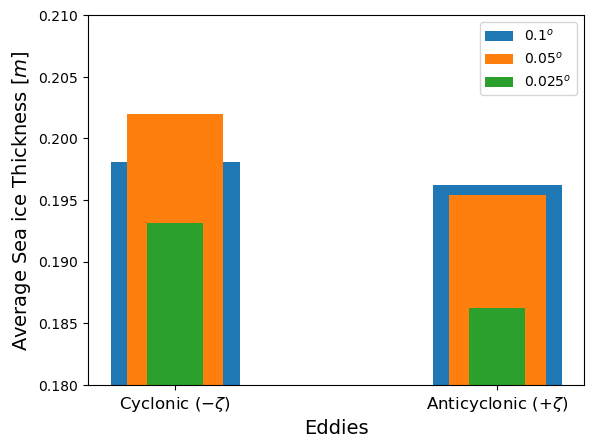

In [115]:
plt.bar(SIT_ζbinned_01.Vorticity_bin,SIT_ζbinned_01.mean('time'),label=r'$0.1^o$')
plt.bar(SIT_ζbinned_005.Vorticity_bin,SIT_ζbinned_005.mean('time'),width=0.6,label=r'$0.05^o$')
plt.bar(SIT_ζbinned_0025.Vorticity_bin,SIT_ζbinned_0025.mean('time'),width=0.35,label=r'$0.025^o$')
plt.legend()
plt.ylabel(r'Average Sea ice Thickness [$m$]',fontsize=14)
plt.xlabel('Eddies',fontsize=14)
plt.xticks(ticks=[-1,1],labels=[r'Cyclonic ($ - \zeta$)',r'Anticyclonic ($ + \zeta$)'],fontsize=12)
plt.ylim(0.18,0.21)

We do seethat the consistent decrease in SIT happens mostly in Anticyclonic eddies, as expected by the EIP theory.  That being said, something itneresting happens with the 1/40th, which I am assuming is that when the increase in EIP start having a cumulative effect

We can re-calculate that in another time, using only the saved matricex of identified eddies, and extracting the SIT in the eddies too in the same way. That will probably be more memory efficient, and might correct any error created by averaging the vorticity and sea ice thicknesses across eddies, instead of respecting individual eddies

# Ekman Pumping

Wecan calcualte the strength of Ekman velocities using the wind stress curl. Using thos vvalues, times the surface area, we can then integrate the Ekman puming under sea ice into volume (or maybe just average Ekman velocities) and see how they differ between simulations

for this calculation, we will use montlhy data, as we wont bin it into vorticity values

In [ ]:
%%time
#importing tau u
τu_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,"tauuo",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yq':'15gb','time':'15gb'}).compute()
τu_005 = importer("panant-005-zstar-ACCESSyr2",catalog,"tauuo",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yq':'15gb','time':'15gb'}).compute()
τu_01 = importer("panant-01-zstar-ACCESSyr2",catalog,"tauuo",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yq':'15gb','time':'15gb'}).compute()
#importing tau v
τv_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,"tauvo",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yq':'15gb','time':'15gb'}).compute()
τv_005 = importer("panant-005-zstar-ACCESSyr2",catalog,"tauvo",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yq':'15gb','time':'15gb'}).compute()
τv_01 = importer("panant-01-zstar-ACCESSyr2",catalog,"tauvo",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yq':'15gb','time':'15gb'}).compute()

### Ekman pumping in Panan01

In [ ]:
%%time
#dxs in all grid points of panan01
dx_xhyh_01 = importer("panant-01-zstar-ACCESSyr2",catalog,"dxt").compute()
dx_xqyh_01 =importer("panant-01-zstar-ACCESSyr2",catalog,'dxCu').compute()
dx_xhyq_01 = importer("panant-01-zstar-ACCESSyr2",catalog,'dxCv').compute()
dx_xqyq_01 = dx_xhyh_01.rename({'xh':'xq','yh':'yq'}).copy()
dx_xqyq_01 =  xr.concat([dx_xqyq_01 [:,-1],dx_xqyq_01 ], dim='xq')
dx_xqyq_01['yq'] = dx_xhyq_01.yq[:-1]
dx_xqyq_01['xq'] = dx_xqyh_01.xq

# #dys in all grid points of panan01
dy_xhyh_01 = importer("panant-01-zstar-ACCESSyr2",catalog,'dyt').compute()
dy_xqyh_01 = importer("panant-01-zstar-ACCESSyr2",catalog,'dyCu').compute()
dy_xhyq_01 = importer("panant-01-zstar-ACCESSyr2",catalog,'dyCv').compute()
dy_xqyq_01 = dy_xhyh_01.rename({'xh':'xq','yh':'yq'}).copy()
dy_xqyq_01=  xr.concat([dy_xqyq_01[:,-1],dy_xqyq_01], dim='xq')
dy_xqyq_01['yq'] = dy_xhyq_01.yq[:-1]
dy_xqyq_01['xq'] = dy_xqyh_01.xq


In [ ]:
#calcualting coriolis
from gsw import f as fcorr
F01 = (1+(dy_xqyq_01*0)) * dy_xqyq_01.yq


In [ ]:
#calculating vorticity
%%time
##### Part 1 of vorticity, dv/dx

# We need to make diff('xh') on V, but to make sure the V's are correct, a Halo is
#first created on the eastern and western side of the domain
dVs_01 = xr.concat([τv_01[:,:,-1],τv_01,τv_01[:,:,0]], dim='xh').diff('xh')
#the resulting data is on xq now, so let's fix that
dVs_01 = dVs_01.rename({'xh':'xq'})
dVs_01['xq'] = τu_01.xq
#now let's devide Dvs (delta done along x's) by the x distances to get dVdx.
#This velow is the first term of the vorticity
dVdx_01 = (dVs_01/dx_xqyq_01).compute()


In [ ]:
%%time
##### Part 2 of vorticity, du/dy

# analogous to Dv, We need to make diff('yh') on U, but to make sure the U's 
#in this case however, we know the domain is not reentrant in y, so we can just
#make the calculation while getting rid of the Southernmost latitude.
#that is not a problem here because the Southernmost latitude is popualted by NaNs
dUs_01 = Us_01.diff('yh')
#the resulting data is on xq now, so let's fix that
dUs_01 = dUs_01.rename({'yh':'yq'})
dUs_01['yq'] = Vs_01.yq[1:-1]
#now let's devide Dus (delta done along y's) by the y distances to get dVdx.
#This below is the second term of the vorticity
dUdy_01 = (dUs_01/dy_xqyq_01).compute()